# Analisis Klasterisasi Pola Kependudukan RT
**Teknik Informatika — Tugas Akhir D3**

**Metode:** K-Means Clustering + Analisis Tren Linear

**Data:** Penduduk 35 RT, Tahun 2021–2025

---
### Alur Analisis
1. Import Library
2. Memuat Dataset
3. Pembersihan & Pra-Pemrosesan Data
4. Feature Engineering
5. Menentukan Jumlah Klaster Optimal
6. Membangun Model K-Means
7. Validasi Klaster
8. Visualisasi Hasil Klaster
9. Analisis Tren & Proyeksi Linear per Klaster
10. Interpretasi Klaster
11. Export Data


# 1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Pengaturan tampilan
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

print('✓ Semua library berhasil diimport')

✓ Semua library berhasil diimport


# 2. Memuat Dataset

Dataset berisi data penduduk **35 RT** selama **5 tahun (2021–2025)**.
Setiap baris merepresentasikan jumlah penduduk laki-laki dan perempuan
pada satu RT di satu tahun tertentu.

In [ ]:
# Load data dari file CSV
# Ganti path sesuai lokasi file kamu
url = 'https://drive.google.com/uc?export=download&id=1N6-bOlzwy-LemuFCYeZpoy-tt2c6xb8v'
df = pd.read_csv(url)

print(f'Jumlah baris  : {len(df)}')
print(f'Jumlah kolom  : {len(df.columns)}')
print(f'Kolom         : {df.columns.tolist()}')
print(f'RT unik       : {df["RT"].nunique()}')
print(f'Tahun         : {sorted(df["Year"].unique())}')

Jumlah baris  : 175
Jumlah kolom  : 4
Kolom         : ['RT', 'Year', 'Male', 'Female']
RT unik       : 35
Tahun         : [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [ ]:
df.head(10)

,RT,Year,Male,Female
0,1,2021,42,189
1,1,2022,739,305
2,1,2023,32,196
3,1,2024,667,89
4,1,2025,174,846
5,2,2021,110,102
6,2,2022,87,37
7,2,2023,479,283
8,2,2024,101,95
9,2,2025,750,502


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   RT      175 non-null    int64
 1   Year    175 non-null    int64
 2   Male    175 non-null    int64
 3   Female  175 non-null    int64
dtypes: int64(4)
memory usage: 5.6 KB


In [ ]:
df.describe()

,RT,Year,Male,Female
count,175.000000,175.000000,175.000000,175.000000
mean,18.000000,2023.000000,222.211429,212.805714
std,10.128485,1.418272,212.816785,197.404442
min,1.000000,2021.000000,2.000000,3.000000
25%,9.000000,2022.000000,58.500000,65.500000
50%,18.000000,2023.000000,157.000000,161.000000
75%,27.000000,2024.000000,335.000000,300.000000
max,35.000000,2025.000000,955.000000,882.000000


# 3. Pembersihan & Pra-Pemrosesan Data

In [ ]:
# Cek missing value
print('Missing value per kolom:')
print(df.isnull().sum())

Missing value per kolom:
RT        0
Year      0
Male      0
Female    0
dtype: int64


In [ ]:
# Cek data duplikat
print(f'Jumlah duplikat: {df.duplicated().sum()}')

Jumlah duplikat: 0


In [ ]:
# Hitung Total penduduk per RT per tahun
df['Total'] = df['Male'] + df['Female']

# Cek hasil
df.head()

,RT,Year,Male,Female,Total
0,1,2021,42,189,231
1,1,2022,739,305,1044
2,1,2023,32,196,228
3,1,2024,667,89,756
4,1,2025,174,846,1020


In [ ]:
# Pivot: ubah ke format RT x Tahun (satu baris = satu RT)
pivot = df.pivot(index='RT', columns='Year', values='Total')

print('Dimensi pivot:', pivot.shape)
pivot.head()

Dimensi pivot: (35, 5)


Year,2021,2022,2023,2024,2025
RT,,,,,
1,231,1044,228,756,1020
2,212,124,762,196,1252
3,209,109,178,292,632
4,168,292,129,329,193
5,595,432,807,1084,772


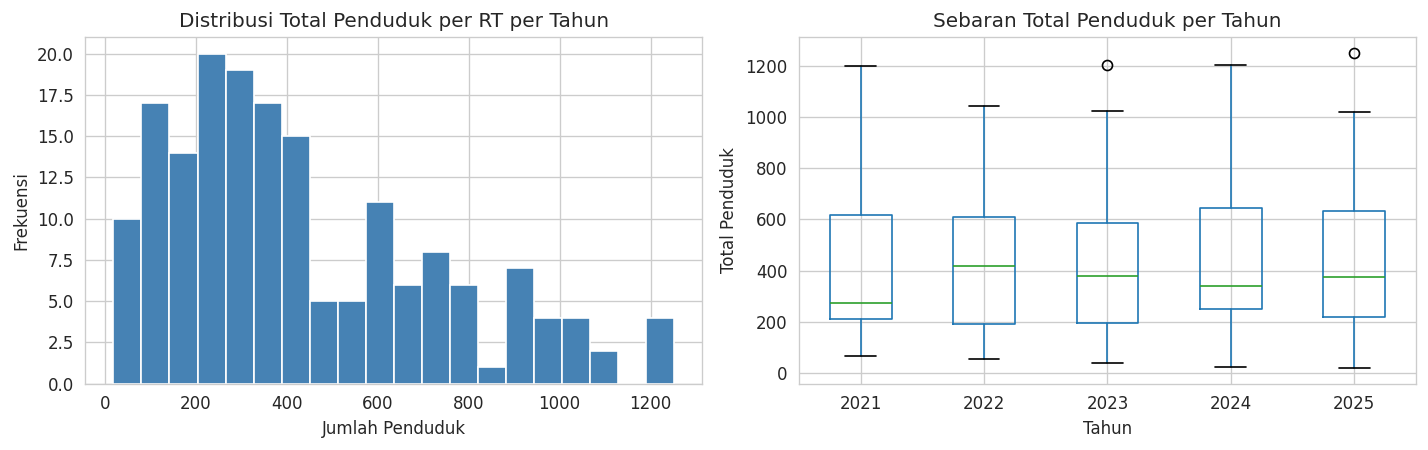

In [ ]:
# Visualisasi distribusi Total penduduk
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['Total'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Total Penduduk per RT per Tahun')
axes[0].set_xlabel('Jumlah Penduduk')
axes[0].set_ylabel('Frekuensi')

# Boxplot per tahun
df.boxplot(column='Total', by='Year', ax=axes[1])
axes[1].set_title('Sebaran Total Penduduk per Tahun')
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('Total Penduduk')
plt.suptitle('')

plt.tight_layout()
plt.show()

# 4. Feature Engineering

Tiga fitur tambahan diturunkan dari deret waktu setiap RT:
- **slope** — arah tren linear (positif = naik, negatif = turun)
- **cv** — koefisien variasi, ukuran volatilitas antar tahun
- **mean_total** — rata-rata populasi sebagai ukuran skala

Fitur ini penting agar K-Means dapat membedakan RT
yang naik vs turun vs stagnan — bukan hanya berdasarkan angka absolut.

In [ ]:
years = np.array([2021, 2022, 2023, 2024, 2025])

# Slope: kemiringan garis tren linear
pivot['slope'] = pivot[years].apply(
    lambda row: np.polyfit(years, row.values, 1)[0], axis=1
)

# CV: koefisien variasi (std/mean)
pivot['cv'] = pivot[years].apply(
    lambda row: row.std() / row.mean(), axis=1
)

# Mean total penduduk
pivot['mean_total'] = pivot[years].mean(axis=1)

print('Fitur yang digunakan untuk clustering:')
print(list(years) + ['slope', 'cv', 'mean_total'])
pivot[['slope', 'cv', 'mean_total']].describe().round(2)

Fitur yang digunakan untuk clustering:
[np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), 'slope', 'cv', 'mean_total']


Year,slope,cv,mean_total
count,35.00,35.00,35.00
mean,2.23,0.65,435.02
std,97.15,0.19,132.06
min,-217.10,0.33,222.20
25%,-21.85,0.51,339.60
50%,21.90,0.64,424.60
75%,61.75,0.76,517.50
max,215.20,1.05,738.00


In [ ]:
# Normalisasi fitur (WAJIB untuk K-Means karena berbasis jarak)
feat_cols = list(years) + ['slope', 'cv', 'mean_total']
X_raw = pivot[feat_cols].values

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f'Dimensi matriks fitur : {X.shape}')
print(f'Mean setelah scaling  : {X.mean(axis=0).round(3)}')
print(f'Std setelah scaling   : {X.std(axis=0).round(3)}')

Dimensi matriks fitur : (35, 8)
Mean setelah scaling  : [-0. -0.  0.  0.  0.  0.  0. -0.]
Std setelah scaling   : [1. 1. 1. 1. 1. 1. 1. 1.]


# 5. Menentukan Jumlah Klaster Optimal

Tiga metode digunakan secara bersamaan:
- **Elbow Method** — cari titik 'siku' pada grafik inertia
- **Silhouette Score** — nilai tertinggi = klaster terbaik (range: -1 s/d 1)
- **Davies-Bouldin Index** — nilai terkecil = klaster terbaik

In [ ]:
K_range = range(2, 9)
inertias, sil_scores, db_scores = [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, lbl))
    db_scores.append(davies_bouldin_score(X, lbl))

# Tampilkan tabel perbandingan
hasil_k = pd.DataFrame({
    'K': list(K_range),
    'Inertia': [round(i, 1) for i in inertias],
    'Silhouette Score': [round(s, 4) for s in sil_scores],
    'Davies-Bouldin': [round(d, 4) for d in db_scores]
})
print(hasil_k.to_string(index=False))

 K  Inertia  Silhouette Score  Davies-Bouldin
 2    214.6            0.1989          1.7351
 3    179.8            0.1852          1.6518
 4    151.7            0.2174          1.3381
 5    134.8            0.1923          1.4626
 6    114.1            0.2444          1.1668
 7    100.7            0.2458          1.1668
 8     91.0            0.2075          1.1118


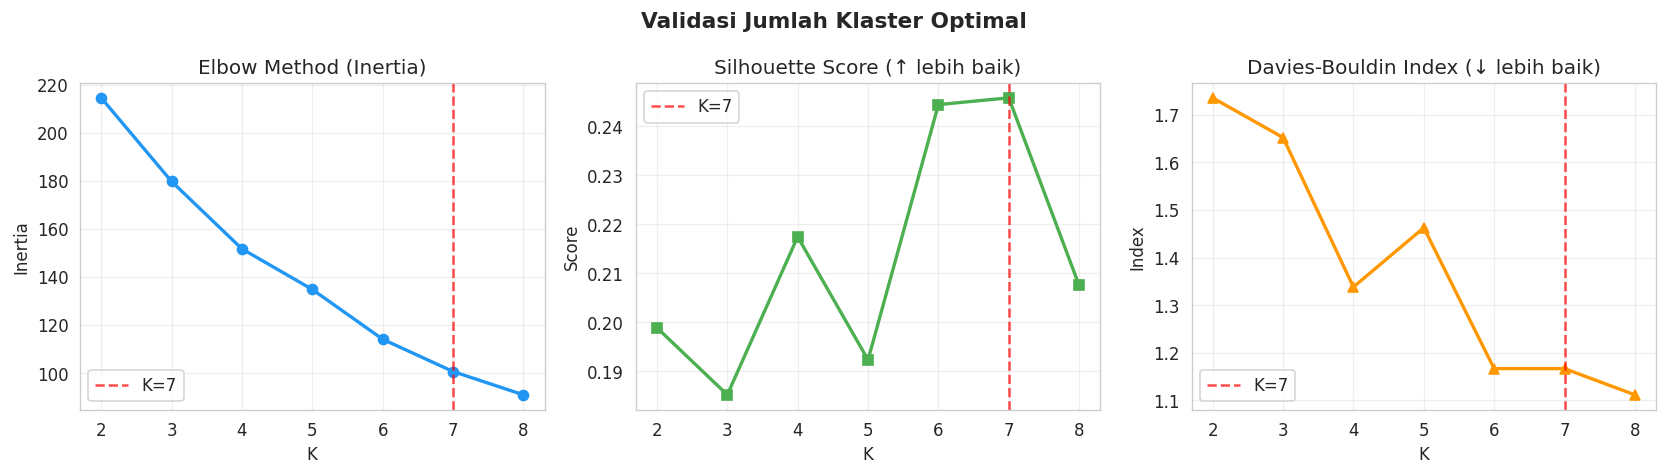


K optimal berdasarkan Silhouette Score tertinggi: K = 7


In [ ]:
# Visualisasi tiga metode
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Validasi Jumlah Klaster Optimal', fontsize=13, fontweight='bold')

best_k = list(K_range)[np.argmax(sil_scores)]

axes[0].plot(K_range, inertias, 'o-', color='#2196F3', lw=2)
axes[0].axvline(best_k, color='red', ls='--', alpha=.7, label=f'K={best_k}')
axes[0].set_title('Elbow Method (Inertia)'); axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia'); axes[0].legend(); axes[0].grid(True, alpha=.3)

axes[1].plot(K_range, sil_scores, 's-', color='#4CAF50', lw=2)
axes[1].axvline(best_k, color='red', ls='--', alpha=.7, label=f'K={best_k}')
axes[1].set_title('Silhouette Score (↑ lebih baik)'); axes[1].set_xlabel('K')
axes[1].set_ylabel('Score'); axes[1].legend(); axes[1].grid(True, alpha=.3)

axes[2].plot(K_range, db_scores, '^-', color='#FF9800', lw=2)
axes[2].axvline(best_k, color='red', ls='--', alpha=.7, label=f'K={best_k}')
axes[2].set_title('Davies-Bouldin Index (↓ lebih baik)'); axes[2].set_xlabel('K')
axes[2].set_ylabel('Index'); axes[2].legend(); axes[2].grid(True, alpha=.3)

plt.tight_layout()
plt.savefig('fig1_validasi_klaster.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nK optimal berdasarkan Silhouette Score tertinggi: K = {best_k}')

# 6. Membangun Model K-Means

In [ ]:
# Gunakan K optimal dari analisis sebelumnya
K_OPTIMAL = best_k   # ubah manual jika perlu

model = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=20)
model.fit(X)

# Simpan label ke pivot
pivot['cluster'] = model.labels_

# Map ke df asal
df['cluster'] = df['RT'].map(pivot['cluster'])

print(f'Model berhasil dilatih dengan K = {K_OPTIMAL}')
print(f'\nJumlah RT per klaster:')
print(pivot['cluster'].value_counts().sort_index())

Model berhasil dilatih dengan K = 7

Jumlah RT per klaster:
cluster
0     5
1     3
2    13
3     2
4     6
5     2
6     4
Name: count, dtype: int64


In [ ]:
# Simpan model
joblib.dump(model, 'model_kmeans_rt.pkl')
joblib.dump(scaler, 'scaler_rt.pkl')
print('✓ Model disimpan: model_kmeans_rt.pkl')
print('✓ Scaler disimpan: scaler_rt.pkl')

✓ Model disimpan: model_kmeans_rt.pkl
✓ Scaler disimpan: scaler_rt.pkl


# 7. Validasi Klaster

- **Silhouette Score**: mendekati 1 = klaster bagus, mendekati 0 = tumpang tindih
- **Davies-Bouldin Index**: mendekati 0 = klaster lebih terpisah (lebih baik)

In [ ]:
labels = model.labels_

sil  = silhouette_score(X, labels)
db   = davies_bouldin_score(X, labels)

print(f'Silhouette Score      : {sil:.4f}')
print(f'Davies-Bouldin Index  : {db:.4f}')
print()
if sil >= 0.5:
    print('Interpretasi: Klaster BAIK (Silhouette ≥ 0.5)')
elif sil >= 0.2:
    print('Interpretasi: Klaster CUKUP (Silhouette 0.2–0.5) — wajar untuk data demografis')
else:
    print('Interpretasi: Klaster LEMAH — pertimbangkan jumlah K yang berbeda')

Silhouette Score      : 0.2458
Davies-Bouldin Index  : 1.1668

Interpretasi: Klaster CUKUP (Silhouette 0.2–0.5) — wajar untuk data demografis


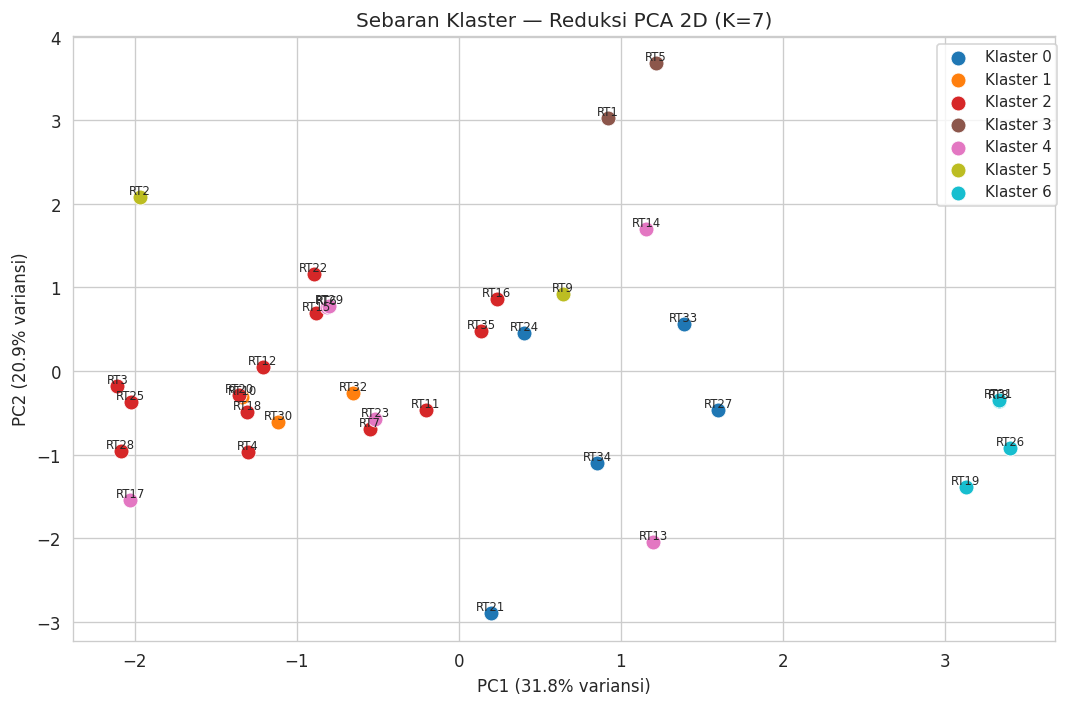

In [ ]:
# Visualisasi PCA 2D untuk melihat sebaran klaster
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = labels
df_pca['RT'] = pivot.index

plt.figure(figsize=(9, 6))
colors = plt.cm.tab10(np.linspace(0, 1, K_OPTIMAL))
for c in sorted(df_pca['Cluster'].unique()):
    sub = df_pca[df_pca['Cluster'] == c]
    plt.scatter(sub['PC1'], sub['PC2'], label=f'Klaster {c}',
                color=colors[c], s=80, edgecolors='white', lw=0.5)
    for _, row in sub.iterrows():
        plt.annotate(f"RT{int(row['RT'])}", (row['PC1'], row['PC2']),
                     fontsize=7, ha='center', va='bottom')

plt.title(f'Sebaran Klaster — Reduksi PCA 2D (K={K_OPTIMAL})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variansi)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variansi)')
plt.legend(bbox_to_anchor=(1.01, 1), fontsize=9)
plt.tight_layout()
plt.savefig('fig2_pca_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

# 8. Visualisasi Hasil Klaster

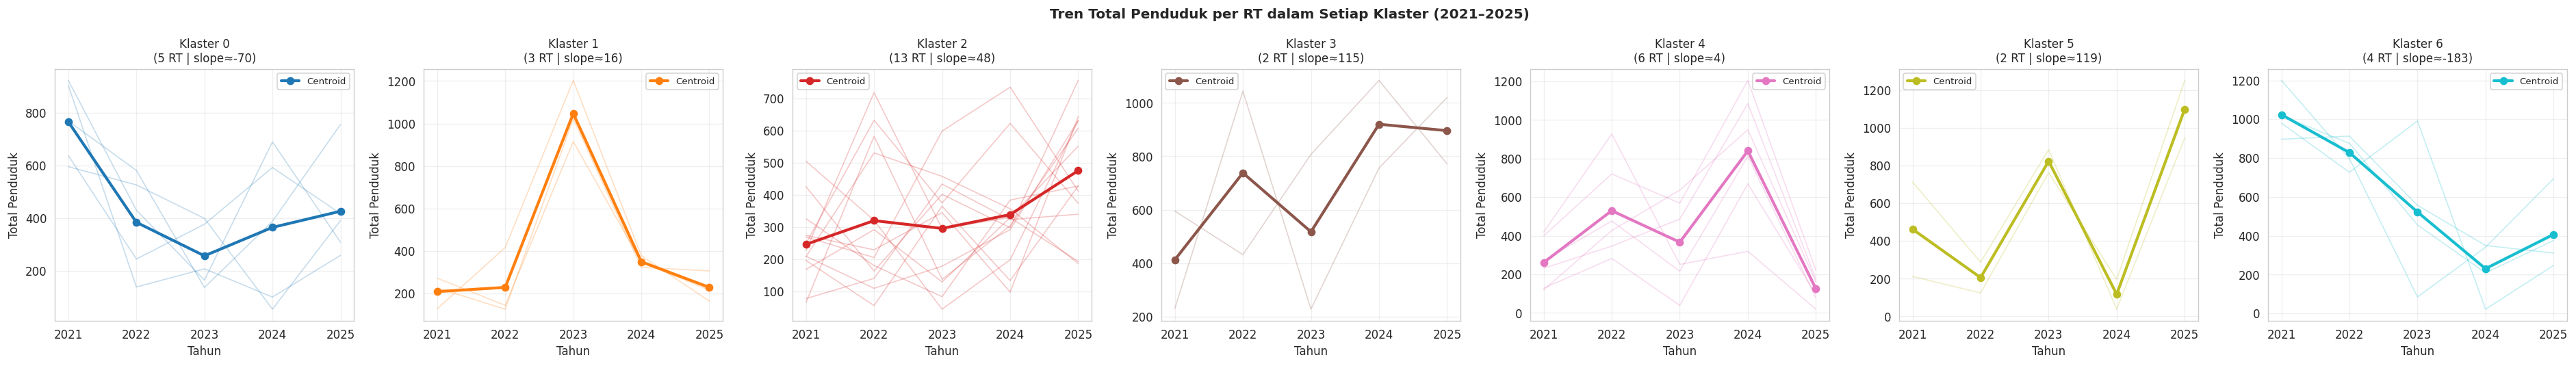

In [ ]:
# Line plot tren per klaster
COLORS = plt.cm.tab10(np.linspace(0, 1, K_OPTIMAL))
n_cls = pivot['cluster'].nunique()
fig, axes = plt.subplots(1, n_cls, figsize=(4.5*n_cls, 4.5), sharey=False)
if n_cls == 1: axes = [axes]
fig.suptitle('Tren Total Penduduk per RT dalam Setiap Klaster (2021–2025)',
             fontsize=12, fontweight='bold')

for ci, ax in enumerate(axes):
    rts = pivot[pivot['cluster'] == ci].index.tolist()
    col = COLORS[ci]
    for rt in rts:
        vals = df[df['RT'] == rt].sort_values('Year')['Total'].values
        ax.plot(years, vals, color=col, alpha=0.25, lw=1)
    centroid = df[df['RT'].isin(rts)].groupby('Year')['Total'].mean()
    ax.plot(years, centroid.values, color=col, lw=2.5, marker='o', label='Centroid')
    sl = pivot.loc[rts, 'slope'].mean()
    ax.set_title(f'Klaster {ci}\n({len(rts)} RT | slope≈{sl:.0f})', fontsize=10)
    ax.set_xlabel('Tahun'); ax.set_ylabel('Total Penduduk')
    ax.legend(fontsize=8); ax.grid(True, alpha=.3)

plt.tight_layout()
plt.savefig('fig3_lineplot_klaster.png', dpi=150, bbox_inches='tight')
plt.show()

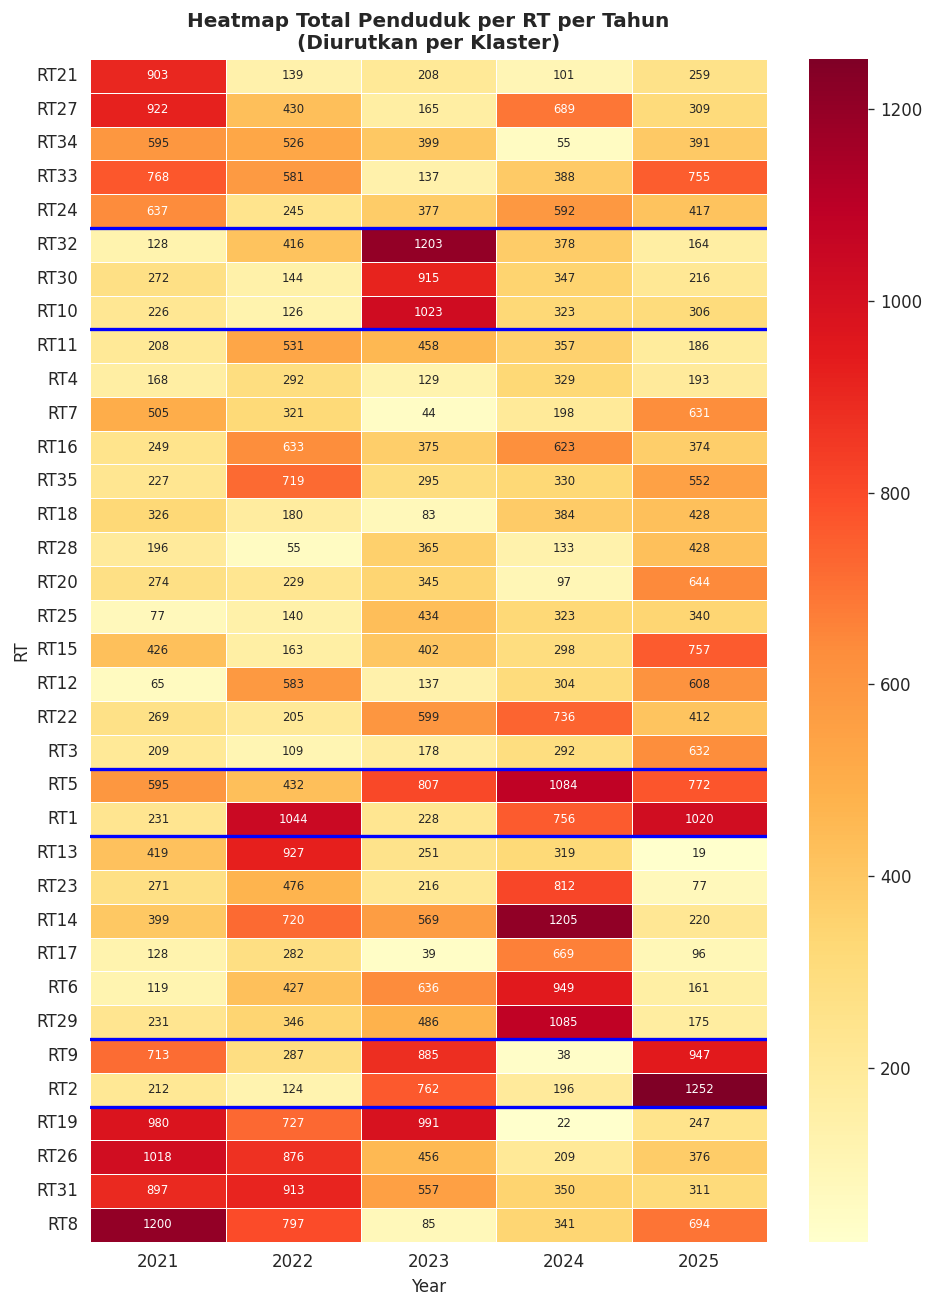

In [ ]:
# Heatmap total penduduk RT x tahun (diurutkan per klaster)
hm = pivot[list(years)].copy()
hm.index = [f'RT{i}' for i in hm.index]
hm = hm.loc[pivot.sort_values(['cluster','slope']).index.map(lambda x: f'RT{x}')]

fig, ax = plt.subplots(figsize=(8, 11))
sns.heatmap(hm, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=.3, ax=ax, annot_kws={'size': 7})
ax.set_title('Heatmap Total Penduduk per RT per Tahun\n(Diurutkan per Klaster)',
             fontsize=12, fontweight='bold')

# Garis batas antar klaster
cum = 0
for ci in sorted(pivot['cluster'].unique()):
    n = (pivot['cluster'] == ci).sum()
    cum += n
    if cum < len(pivot):
        ax.axhline(cum, color='blue', lw=2)

plt.tight_layout()
plt.savefig('fig4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 9. Analisis Tren & Proyeksi Linear per Klaster

Karena data historis hanya mencakup **5 titik waktu (2021–2025)**,
metode yang digunakan adalah **regresi linear** per klaster.
Proyeksi dilakukan untuk tahun **2026–2028** (3 tahun ke depan).

> ⚠️ Proyeksi bersifat **indikatif** — asumsi tren berjalan lurus.
> Cocok untuk D3, tidak memerlukan ARIMA/Prophet.

In [ ]:
# Agregasi data per klaster per tahun
df_ts = df.groupby(['cluster', 'Year'])['Total'].mean().reset_index()

# Regresi linear dan proyeksi 2026–2028
forecast_rows = []
print('Persamaan regresi per klaster:')
for c in sorted(df_ts['cluster'].unique()):
    sub = df_ts[df_ts['cluster'] == c]
    coef = np.polyfit(sub['Year'], sub['Total'], 1)
    a, b = coef
    print(f'  Klaster {c}: Total = {a:.2f} x Tahun + ({b:.0f})')
    for yr in [2026, 2027, 2028]:
        forecast_rows.append({
            'cluster': c, 'Year': yr,
            'Total': np.polyval(coef, yr), 'tipe': 'proyeksi'
        })

df_ts['tipe'] = 'aktual'
df_forecast = pd.DataFrame(forecast_rows)
df_all = pd.concat([df_ts, df_forecast], ignore_index=True)

Persamaan regresi per klaster:
  Klaster 0: Total = -69.68 x Tahun + (141402)
  Klaster 1: Total = 16.07 x Tahun + (-32090)
  Klaster 2: Total = 47.82 x Tahun + (-96395)
  Klaster 3: Total = 114.80 x Tahun + (-231543)
  Klaster 4: Total = 3.72 x Tahun + (-7095)
  Klaster 5: Total = 118.55 x Tahun + (-239285)
  Klaster 6: Total = -183.12 x Tahun + (371064)


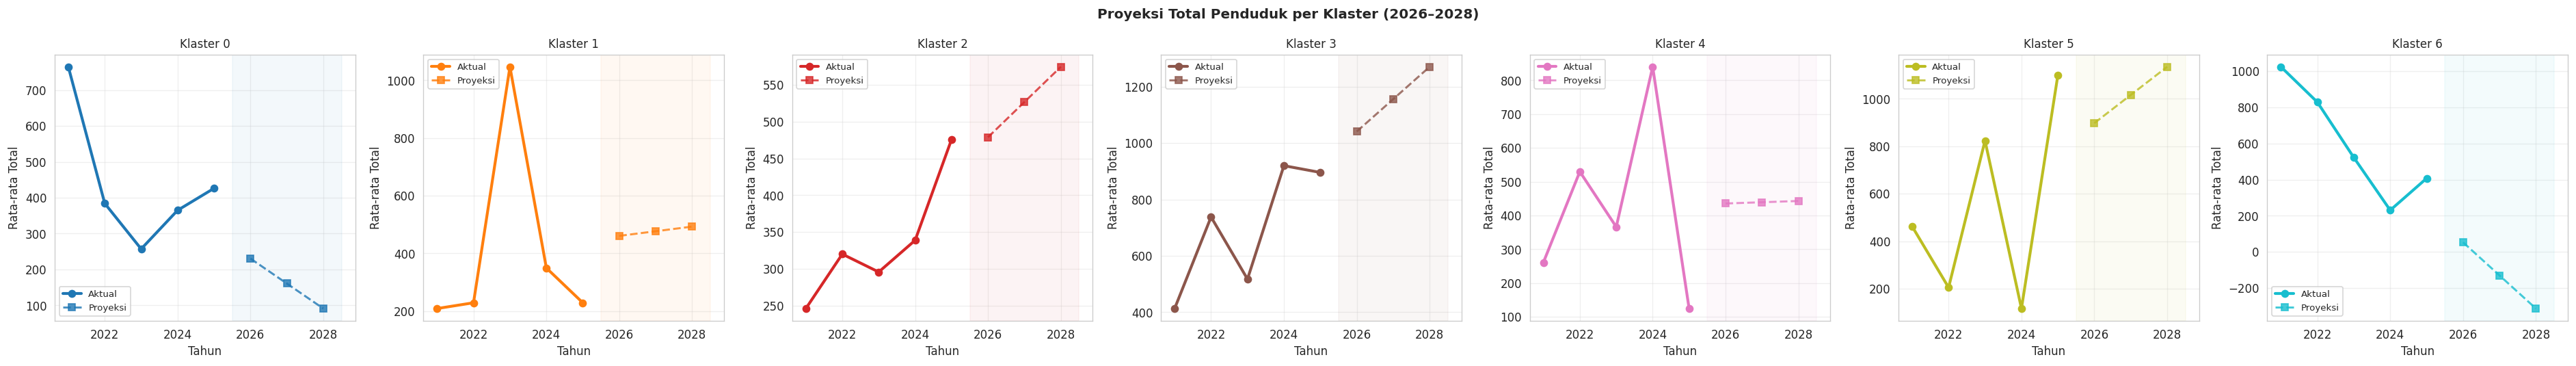

In [ ]:
# Visualisasi forecast
n_cls = df_ts['cluster'].nunique()
fig, axes = plt.subplots(1, n_cls, figsize=(4.5*n_cls, 4.5))
if n_cls == 1: axes = [axes]
fig.suptitle('Proyeksi Total Penduduk per Klaster (2026–2028)',
             fontsize=12, fontweight='bold')

for ci, ax in enumerate(axes):
    col = COLORS[ci]
    actual  = df_all[(df_all['cluster'] == ci) & (df_all['tipe'] == 'aktual')]
    fcast   = df_all[(df_all['cluster'] == ci) & (df_all['tipe'] == 'proyeksi')]
    ax.plot(actual['Year'], actual['Total'], 'o-', color=col, lw=2.5, label='Aktual')
    ax.plot(fcast['Year'],  fcast['Total'],  's--', color=col, lw=1.8, alpha=.8, label='Proyeksi')
    ax.axvspan(2025.5, 2028.5, alpha=0.05, color=col)
    ax.set_title(f'Klaster {ci}', fontsize=10)
    ax.set_xlabel('Tahun'); ax.set_ylabel('Rata-rata Total')
    ax.legend(fontsize=8); ax.grid(True, alpha=.3)

plt.tight_layout()
plt.savefig('fig5_proyeksi.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Tabel ringkasan proyeksi
tbl = df_all[df_all['tipe']=='proyeksi'].pivot(index='Year', columns='cluster', values='Total').round(1)
tbl.columns = [f'Klaster {c}' for c in tbl.columns]
print('Proyeksi rata-rata total penduduk per klaster:')
tbl

Proyeksi rata-rata total penduduk per klaster:


,Klaster 0,Klaster 1,Klaster 2,Klaster 3,Klaster 4,Klaster 5,Klaster 6
Year,,,,,,,
2026,230.5,460.7,478.7,1041.3,435.4,897.3,53.0
2027,160.8,476.7,526.5,1156.1,439.2,1015.8,-130.2
2028,91.1,492.8,574.3,1270.9,442.9,1134.4,-313.3


# 10. Interpretasi Klaster

Ringkasan karakteristik setiap klaster berdasarkan:
- **slope** — arah tren (positif/negatif)
- **cv** — volatilitas
- **mean_total** — skala populasi

In [ ]:
# Ringkasan statistik per klaster
summary = pivot.groupby('cluster')[['slope', 'cv', 'mean_total']].mean().round(2)
summary['jumlah_rt'] = pivot.groupby('cluster').size()
summary['rt_list'] = pivot.groupby('cluster').apply(
    lambda x: x.index.tolist()
)

# Label otomatis
def label_cluster(row):
    if row['slope'] > 80:      return '🔺 Naik Kuat'
    elif row['slope'] > 20:    return '↗ Naik Sedang'
    elif row['slope'] > -20:   return '➡ Stabil/Stagnan'
    elif row['slope'] > -100:  return '↘ Turun Sedang'
    else:                      return '🔻 Turun Kuat'

summary['karakteristik'] = summary.apply(label_cluster, axis=1)

print('=== RINGKASAN HASIL KLASTERISASI ===')
for c, row in summary.iterrows():
    print(f'\nKlaster {c} [{row["karakteristik"]}]')
    print(f'  RT        : {row["rt_list"]}')
    print(f'  Jml RT    : {int(row["jumlah_rt"])}')
    print(f'  Slope     : {row["slope"]:.2f} (jiwa/tahun)')
    print(f'  CV        : {row["cv"]:.2f}')
    print(f'  Mean Total: {row["mean_total"]:.1f}')

=== RINGKASAN HASIL KLASTERISASI ===

Klaster 0 [↘ Turun Sedang]
  RT        : [21, 24, 27, 33, 34]
  Jml RT    : 5
  Slope     : -69.68 (jiwa/tahun)
  CV        : 0.60
  Mean Total: 439.5

Klaster 1 [➡ Stabil/Stagnan]
  RT        : [10, 30, 32]
  Jml RT    : 3
  Slope     : 16.07 (jiwa/tahun)
  CV        : 0.89
  Mean Total: 412.5

Klaster 2 [↗ Naik Sedang]
  RT        : [3, 4, 7, 11, 12, 15, 16, 18, 20, 22, 25, 28, 35]
  Jml RT    : 13
  Slope     : 47.82 (jiwa/tahun)
  CV        : 0.56
  Mean Total: 335.3

Klaster 3 [🔺 Naik Kuat]
  RT        : [1, 5]
  Jml RT    : 2
  Slope     : 114.80 (jiwa/tahun)
  CV        : 0.47
  Mean Total: 696.9

Klaster 4 [➡ Stabil/Stagnan]
  RT        : [6, 13, 14, 17, 23, 29]
  Jml RT    : 6
  Slope     : 3.72 (jiwa/tahun)
  CV        : 0.81
  Mean Total: 424.3

Klaster 5 [🔺 Naik Kuat]
  RT        : [2, 9]
  Jml RT    : 2
  Slope     : 118.55 (jiwa/tahun)
  CV        : 0.82
  Mean Total: 541.6

Klaster 6 [🔻 Turun Kuat]
  RT        : [8, 19, 26, 31]
  Jml

In [ ]:
# Tabel ringkasan siap laporan
tbl_laporan = summary[['jumlah_rt', 'slope', 'cv', 'mean_total', 'karakteristik']].copy()
tbl_laporan.columns = ['Jumlah RT', 'Slope Rata-rata', 'CV Rata-rata', 'Mean Total', 'Karakteristik']
tbl_laporan

,Jumlah RT,Slope Rata-rata,CV Rata-rata,Mean Total,Karakteristik
cluster,,,,,
0,5,-69.68,0.60,439.52,↘ Turun Sedang
1,3,16.07,0.89,412.47,➡ Stabil/Stagnan
2,13,47.82,0.56,335.26,↗ Naik Sedang
3,2,114.80,0.47,696.90,🔺 Naik Kuat
4,6,3.72,0.81,424.30,➡ Stabil/Stagnan
5,2,118.55,0.82,541.60,🔺 Naik Kuat
6,4,-183.12,0.62,602.35,🔻 Turun Kuat


# 11. Export Data

Simpan hasil clustering ke CSV untuk dilampirkan di laporan.

In [ ]:
# Export data lengkap + label klaster
df_export = df[['RT', 'Year', 'Male', 'Female', 'Total', 'cluster']]\
              .sort_values(['cluster', 'RT', 'Year'])
df_export.to_csv('data_clustering_rt.csv', index=False)
print('✓ Data tersimpan: data_clustering_rt.csv')
print(f'  Total baris: {len(df_export)}')
df_export.head(10)

✓ Data tersimpan: data_clustering_rt.csv
  Total baris: 175


,RT,Year,Male,Female,Total,cluster
100,21,2021,222,681,903,0
101,21,2022,73,66,139,0
102,21,2023,83,125,208,0
103,21,2024,5,96,101,0
104,21,2025,209,50,259,0
115,24,2021,320,317,637,0
116,24,2022,211,34,245,0
117,24,2023,56,321,377,0
118,24,2024,579,13,592,0
119,24,2025,226,191,417,0


In [ ]:
# Export ringkasan klaster
summary_export = summary[['jumlah_rt', 'slope', 'cv', 'mean_total', 'karakteristik']].copy()
summary_export.to_csv('summary_klaster_rt.csv')
print('✓ Ringkasan tersimpan: summary_klaster_rt.csv')

✓ Ringkasan tersimpan: summary_klaster_rt.csv


In [ ]:
# Export proyeksi
df_all.to_csv('proyeksi_klaster_rt.csv', index=False)
print('✓ Proyeksi tersimpan: proyeksi_klaster_rt.csv')
print()
print('=== SELESAI ===')
print('File yang dihasilkan:')
print('  📊 data_clustering_rt.csv    — data + label klaster')
print('  📊 summary_klaster_rt.csv   — ringkasan per klaster')
print('  📊 proyeksi_klaster_rt.csv  — proyeksi 2026-2028')
print('  🤖 model_kmeans_rt.pkl      — model tersimpan')
print('  🔧 scaler_rt.pkl            — scaler tersimpan')
print('  🖼  fig1_validasi_klaster.png')
print('  🖼  fig2_pca_cluster.png')
print('  🖼  fig3_lineplot_klaster.png')
print('  🖼  fig4_heatmap.png')
print('  🖼  fig5_proyeksi.png')

✓ Proyeksi tersimpan: proyeksi_klaster_rt.csv

=== SELESAI ===
File yang dihasilkan:
  📊 data_clustering_rt.csv    — data + label klaster
  📊 summary_klaster_rt.csv   — ringkasan per klaster
  📊 proyeksi_klaster_rt.csv  — proyeksi 2026-2028
  🤖 model_kmeans_rt.pkl      — model tersimpan
  🔧 scaler_rt.pkl            — scaler tersimpan
  🖼  fig1_validasi_klaster.png
  🖼  fig2_pca_cluster.png
  🖼  fig3_lineplot_klaster.png
  🖼  fig4_heatmap.png
  🖼  fig5_proyeksi.png


---
*End of Notebook*